# Машинное обучение. Практическое задание №1

**Авторы:** Тамплон Андрей, Иванов Павел

Исследуем вакансии в сфере ИИ: какие данные требуют очистки и какие признаки связаны с зарплатой.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('deep')

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

В файле используется разделитель `;` и кодировка UTF-8 с BOM. Указываем их при чтении.

In [2]:
df = pd.read_csv('ai_job_dataset_upd.csv', sep=';', encoding='utf-8-sig')
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376.0,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076.0,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895.0,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268.0,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626.0,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974.0,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215.0,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345.0,8.6,Future Systems
4,AI00005,AI Consultant,54624.0,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989.0,6.6,Advanced Robotics


## 1. Описание датасета

In [3]:
print(f'Наблюдений: {df.shape[0]}')
print(f'Признаков:  {df.shape[1]}')
print(f'Явных дубликатов строк: {df.duplicated().sum()}')
print(f'Дубликатов job_id:      {df["job_id"].duplicated().sum()}')

Наблюдений: 15000
Признаков:  19
Явных дубликатов строк: 0
Дубликатов job_id:      0


In [4]:
info = pd.DataFrame({
    'тип': df.dtypes.astype(str),
    'пропусков': df.isna().sum(),
    'доля пропусков, %': (df.isna().mean() * 100).round(2),
    'уникальных': df.nunique(),
})
info

,тип,пропусков,"доля пропусков, %",уникальных
job_id,object,0,0.00,15000
job_title,object,0,0.00,20
salary_usd,float64,10,0.07,14305
salary_currency,object,0,0.00,3
experience_level,object,0,0.00,4
employment_type,object,0,0.00,4
company_location,object,0,0.00,20
company_size,object,0,0.00,3
employee_residence,object,2,0.01,24
remote_ratio,int64,0,0.00,3


В таблице 15 000 вакансий и 19 признаков. Дубликатов строк и повторяющихся `job_id` нет.

Всего 44 пропуска, больше всего в `benefits_score`: 16, или 0,11 % строк. Пропуски обработаем в разделе 4.

В описании задания указан `salary_local`, но в файле его нет. Вместо него есть `company_name`.

In [5]:
scales = pd.DataFrame([
    ('job_id',                 'номинальная', 'идентификатор'),
    ('job_title',              'номинальная', '20 должностей'),
    ('salary_usd',             'отношений',   'целевая переменная'),
    ('salary_currency',        'номинальная', 'USD / EUR / GBP'),
    ('experience_level',       'порядковая',  'EN < MI < SE < EX'),
    ('employment_type',        'номинальная', 'FT / PT / CT / FL'),
    ('company_location',       'номинальная', '20 стран'),
    ('company_size',           'порядковая',  'S < M < L'),
    ('employee_residence',     'номинальная', f'{df["employee_residence"].nunique()} исходных значения'),
    ('remote_ratio',           'порядковая',  '0 < 50 < 100'),
    ('required_skills',        'номинальная', 'мультизначный список'),
    ('education_required',     'порядковая',  'Associate < Bachelor < Master < PhD'),
    ('years_experience',       'отношений',   'счётный признак'),
    ('industry',               'номинальная', '23 значения'),
    ('posting_date',           'интервальная','дата'),
    ('application_deadline',   'интервальная','дата'),
    ('job_description_length', 'отношений',   'число символов'),
    ('benefits_score',         'интервальная','балл 1-10'),
    ('company_name',           'номинальная', '16 компаний'),
], columns=['признак', 'шкала', 'комментарий'])
scales

,признак,шкала,комментарий
0,job_id,номинальная,идентификатор
1,job_title,номинальная,20 должностей
2,salary_usd,отношений,целевая переменная
3,salary_currency,номинальная,USD / EUR / GBP
4,experience_level,порядковая,EN < MI < SE < EX
5,employment_type,номинальная,FT / PT / CT / FL
6,company_location,номинальная,20 стран
7,company_size,порядковая,S < M < L
8,employee_residence,номинальная,24 исходных значения
9,remote_ratio,порядковая,0 < 50 < 100


Шкалы указаны в таблице выше. Для категорий будем сравнивать частоты, для упорядоченных значений использовать ранговые методы, для числовых дополнительно считать среднее и разброс.

`remote_ratio` рассматриваем как три формата работы: офис, гибрид и удалённая работа. Для `benefits_score` принимаем равные интервалы между баллами.

В `employee_residence` 24 уникальных значения: 20 названий стран, три варианта написания и значение `8888`. Исправим их в разделе 4.

## 2. Одномерный разведочный анализ

Посмотрим на зарплату, опыт, уровень позиции, формат работы и отрасль.

### 2.1. Зарплата

Проверим разброс и необычные значения `salary_usd`. Для числового признака рассчитаем описательные статистики. Гистограмма покажет форму распределения. На boxplot будут видны медиана, разброс и возможные выбросы.

In [6]:
s = df['salary_usd']
print(s.describe().round(1).to_string())
print(f'\nАсимметрия: {s.skew():.2f}')
print(f'Эксцесс:    {s.kurtosis():.2f}')

count       14990.0
mean       123206.9
std        825496.0
min          -999.0
25%         70154.8
50%         99618.0
75%        146399.0
max      99999999.0

Асимметрия: 118.39
Эксцесс:    14301.52


Зарплаты от −999 до почти 100 млн долларов выглядят ошибочными. Из-за них стандартное отклонение достигает 825 тысяч, а асимметрия 118. Посмотрим крайние значения.

In [7]:
print('Наименьшие значения:', np.sort(s.dropna().values)[:12])
print('Наибольшие значения:', np.sort(s.dropna().values)[-5:])
print(f'\nЗначений меньше 1000: {(s < 1000).sum()}')
print(f'Значений больше 1 млн: {(s > 1e6).sum()}')

Наименьшие значения: [-9.9900e+02 -7.8000e+01 -1.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00
  3.0000e+00  5.0000e+00  1.0000e+01  1.2000e+01  4.5000e+01  3.2519e+04]
Наибольшие значения: [  398084.   399095.  9383302. 10000000. 99999999.]

Значений меньше 1000: 11
Значений больше 1 млн: 3


В верхней части распределения после 399 095 долл. следуют значения 9 383 302, 10 000 000 и 99 999 999 долл. Из-за большого разрыва считаем эти три наблюдения подозрительными и исключаем из дальнейшего анализа. Порог 1 млн долл. выбран внутри этого разрыва, а не как максимально допустимая зарплата.

В нижней части распределения 11 значений лежат в диапазоне от −999 до 45 долл., а следующее значение равно 32 519 долл. Исключим эти 11 наблюдений, установив нижнюю границу 1 000 долл. внутри разрыва. Всего исключаем 14 наблюдений.

In [8]:
mask_valid = s.between(1000, 1e6)
s_clean = s[mask_valid]

print(s_clean.describe().round(1).to_string())
print(f'\nАсимметрия: {s_clean.skew():.2f}')

q1, q3 = s_clean.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = ((s_clean < low) | (s_clean > high)).sum()
print(f'Границы Тьюки: {low:,.0f} / {high:,.0f}')
print(f'За границами:  {out} наблюдений ({out / len(s_clean) * 100:.2f} %)')

count     14976.0
mean     115350.5
std       60267.7
min       32519.0
25%       70187.5
50%       99658.5
75%      146408.5
max      399095.0

Асимметрия: 1.25
Границы Тьюки: -44,144 / 260,740
За границами:  483 наблюдений (3.23 %)


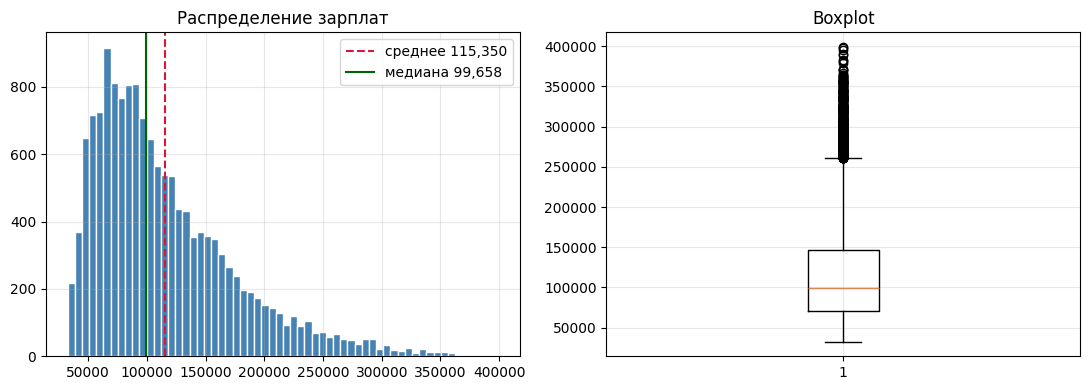

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(s_clean, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(s_clean.mean(), color='crimson', ls='--', label=f'среднее {s_clean.mean():,.0f}')
axes[0].axvline(s_clean.median(), color='darkgreen', ls='-', label=f'медиана {s_clean.median():,.0f}')
axes[0].set_title('Распределение зарплат')
axes[0].legend()

axes[1].boxplot(s_clean)
axes[1].set_title('Boxplot')

plt.tight_layout()
plt.show()

После очистки медиана равна 99 658 долл., среднее 115 350 долл., значения лежат в диапазоне 32,5–399 тыс. долл. Распределение скошено вправо: асимметрия 1,25.

За верхней границей Тьюки остались 483 вакансии (3,2 %). Сохраним их: одна высокая зарплата ещё не означает ошибку.

### 2.2. Требуемый опыт

В `years_experience` 20 целочисленных значений. Сравним их частоты на столбчатой диаграмме, посчитаем среднее и разброс. Boxplot поможет проверить выбросы.

In [10]:
y = df['years_experience']
print(y.describe().round(2).to_string())
print(f'\nАсимметрия: {y.skew():.2f}')
print(f'Мода: {y.mode().values}')

count    15000.00
mean         6.25
std          5.55
min          0.00
25%          2.00
50%          5.00
75%         10.00
max         19.00

Асимметрия: 0.78
Мода: [0]


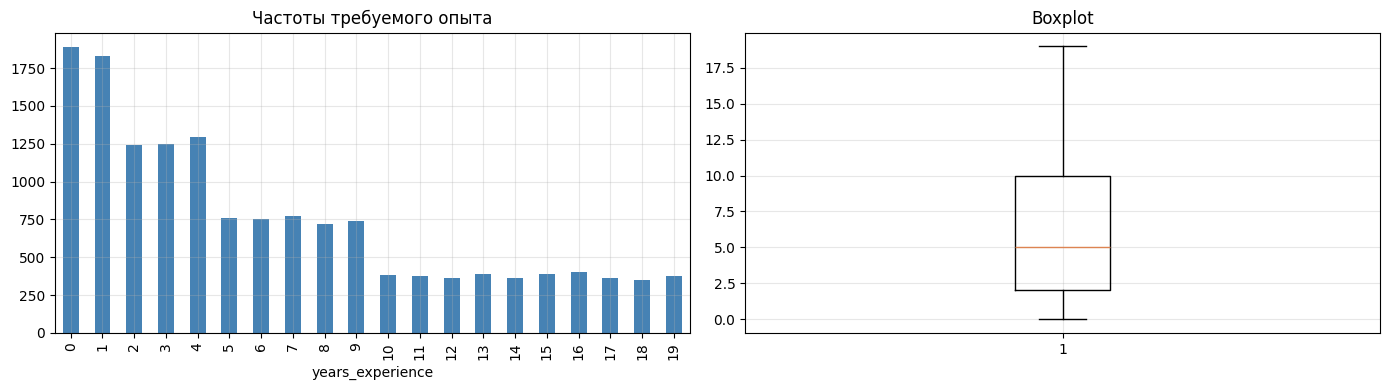

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Частоты требуемого опыта')
axes[1].boxplot(y)
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

Требуемый опыт составляет от 0 до 19 лет, медиана равна 5, среднее 6,25. Чаще встречаются вакансии с небольшим опытом, асимметрия равна 0,78. Пропусков и заметных аномалий нет; для модели можно масштабировать признак.

### 2.3. Уровень позиции

Уровни `experience_level` упорядочены от EN до EX. Сравним их частоты и доли на столбчатой диаграмме.

                  частота  доля, %
experience_level                  
EN                   3718    24.79
MI                   3781    25.21
SE                   3741    24.94
EX                   3760    25.07


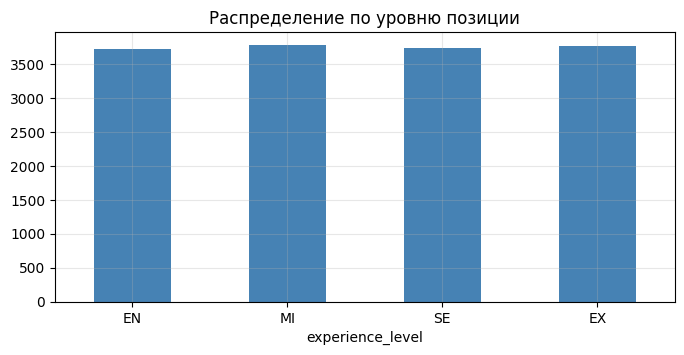

In [12]:
order = ['EN', 'MI', 'SE', 'EX']
freq = df['experience_level'].value_counts().reindex(order)
print(pd.DataFrame({
    'частота': freq,
    'доля, %': (freq / len(df) * 100).round(2),
}).to_string())

freq.plot(kind='bar', color='steelblue', figsize=(8, 3.5))
plt.title('Распределение по уровню позиции')
plt.xticks(rotation=0)
plt.show()

Все четыре уровня представлены почти поровну: 3 718–3 781 вакансия, или 24,8–25,2 % на категорию.

### 2.4. Формат работы

Для `remote_ratio` сравним частоты трёх форматов на столбчатой диаграмме.

                формат  частота  доля, %
remote_ratio                            
0                 офис     5075    33.83
50              гибрид     5005    33.37
100           удалённо     4920    32.80


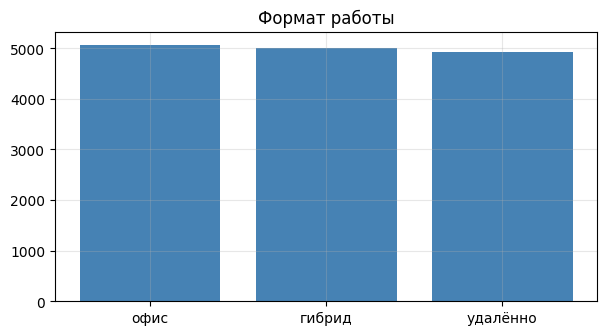

In [13]:
labels = {0: 'офис', 50: 'гибрид', 100: 'удалённо'}
freq = df['remote_ratio'].value_counts().sort_index()
print(pd.DataFrame({
    'формат': [labels[i] for i in freq.index],
    'частота': freq.values,
    'доля, %': (freq.values / len(df) * 100).round(2),
}, index=freq.index).to_string())

plt.figure(figsize=(7, 3.5))
plt.bar([labels[i] for i in freq.index], freq.values, color='steelblue')
plt.title('Формат работы')
plt.show()

Офисных вакансий 33,8 %, гибридных 33,4 %, удалённых 32,8 %. Все три формата представлены примерно одинаково.

### 2.5. Отрасль

У отраслей нет естественного порядка, поэтому сравним частоты и проверим редкие значения. На диаграмме будет видно, насколько равномерно представлены основные отрасли.

In [14]:
freq = df['industry'].value_counts(dropna=False)
print(f'Уникальных значений: {df["industry"].nunique()}')
print(f'Пропусков: {df["industry"].isna().sum()}\n')
print(pd.DataFrame({
    'частота': freq,
    'доля, %': (freq / len(df) * 100).round(2),
}).to_string())

Уникальных значений: 23
Пропусков: 3

                    частота  доля, %
industry                            
Retail                 1061     7.07
Media                  1045     6.97
Consulting             1020     6.80
Automotive             1018     6.79
Technology             1011     6.74
Real Estate            1007     6.71
Healthcare              997     6.65
Government              996     6.64
Transportation          995     6.63
Telecommunications      995     6.63
Finance                 984     6.56
Energy                  976     6.51
Gaming                  967     6.45
Manufacturing           961     6.41
Education               956     6.37
NaN                       3     0.02
Government                1     0.01
Retail_                   1     0.01
manufacturing             1     0.01
Transport                 1     0.01
Governmnt                 1     0.01
Retail                    1     0.01
Telecom                   1     0.01
9999                      1     0.01


У большинства отраслей около тысячи вакансий, но несколько названий встречаются по одному разу. Выведем их через `repr`, чтобы увидеть лишние пробелы.

In [15]:
rare = freq[freq < 5]
print('Редкие значения (repr):')
for value, count in rare.items():
    print(f'  {value!r}: {count}')

Редкие значения (repr):
  nan: 3
  'Government ': 1
  'Retail_': 1
  'manufacturing': 1
  'Transport': 1
  'Governmnt': 1
  'Retail ': 1
  'Telecom': 1
  '9999': 1


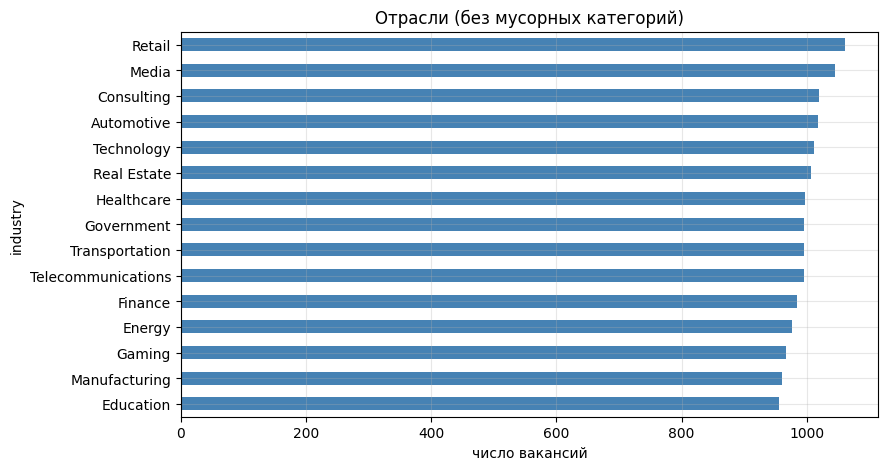

In [16]:
freq[freq >= 5].plot(kind='barh', figsize=(9, 5), color='steelblue')
plt.title('Отрасли (без мусорных категорий)')
plt.xlabel('число вакансий')
plt.gca().invert_yaxis()
plt.show()

Из 23 значений 15 обозначают основные отрасли. Ещё семь являются вариантами написания: `'Government '`, `'Retail '`, `'Retail_'`, `'manufacturing'`, `'Governmnt'`, `'Transport'`, `'Telecom'`. Их объединим с правильными названиями, а `'9999'` обработаем как пропуск.

Основные отрасли представлены примерно поровну: от 956 до 1 061 вакансии. Объединять их не нужно. Найденные ошибки и пропуски обработаем в разделе 4.

## 3. Двумерный разведочный анализ

Целевая переменная: `salary_usd`. Проверим её связь с опытом, уровнем позиции, размером компании, форматом работы и образованием.

Исключим 14 подозрительных зарплат и 10 строк без зарплаты. Останется 14 976 вакансий.

In [17]:
d = df[df['salary_usd'].between(1000, 1e6)].copy()
print(f'Наблюдений для анализа: {len(d)} (отложено {len(df) - len(d)})')

Наблюдений для анализа: 14976 (отложено 24)


### 3.1. Зарплата и опыт работы

Проверим, растёт ли зарплата с опытом. Возьмём Спирмена: он подходит для монотонной связи, которая может быть нелинейной. Для сравнения рассчитаем Пирсона. Диаграмма рассеяния покажет разброс, а график медиан покажет общий ход зависимости.

In [18]:
r_p, p_p = stats.pearsonr(d['years_experience'], d['salary_usd'])
r_s, p_s = stats.spearmanr(d['years_experience'], d['salary_usd'])
print(f'Пирсон:   r = {r_p:.3f},  p = {p_p:.2e}')
print(f'Спирмен:  rho = {r_s:.3f},  p = {p_s:.2e}')

Пирсон:   r = 0.737,  p = 0.00e+00
Спирмен:  rho = 0.792,  p = 0.00e+00


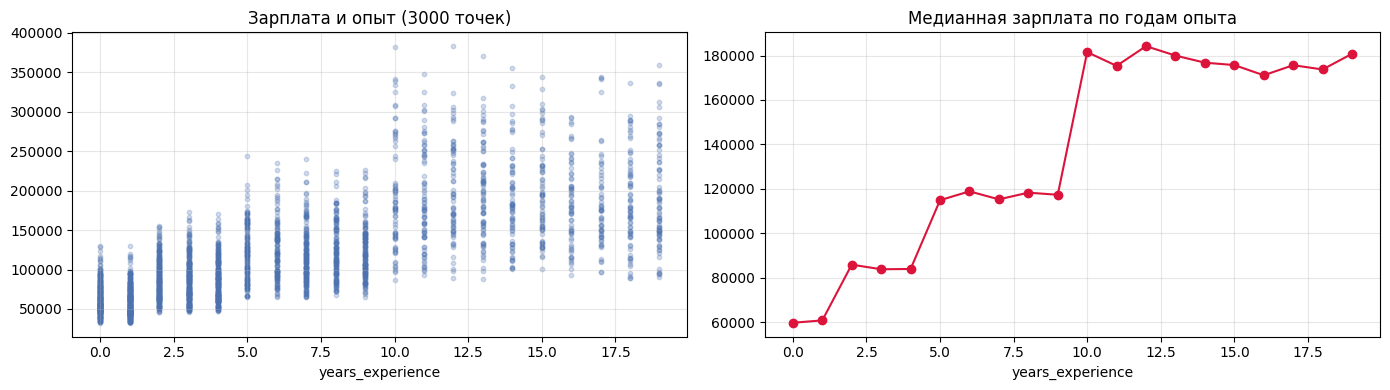

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sample = d.sample(3000, random_state=42)
axes[0].scatter(sample['years_experience'], sample['salary_usd'], alpha=0.25, s=10)
axes[0].set_title('Зарплата и опыт (3000 точек)')
axes[0].set_xlabel('years_experience')

med = d.groupby('years_experience')['salary_usd'].median()
axes[1].plot(med.index, med.values, marker='o', color='crimson')
axes[1].set_title('Медианная зарплата по годам опыта')
axes[1].set_xlabel('years_experience')

plt.tight_layout()
plt.show()

Связь сильная и положительная: Спирмен 0,79, Пирсон 0,74. Оба p-value очень малы и округляются до нуля.

Рост зарплаты по стажу имеет ступенчатый характер: диапазоны опыта соответствуют уровням позиции. Медианы зарплат по этим группам составляют 60,4 тыс. долл. для EN (0–1 год), 84,7 тыс. для MI (2–4 года), 116,9 тыс. для SE (5–9 лет) и 177,5 тыс. для EX (10–19 лет). Общая корреляция не отделяет связь зарплаты со стажем от различий между уровнями. Связь внутри каждого уровня проверим в разделе 5.3.

### 3.2. Зарплата и уровень позиции

Спирмен учтёт порядок EN, MI, SE, EX. Краскел–Уоллис проверит различия зарплат между группами без предположения о нормальности. Boxplot покажет медианы и разброс.

                  count    median      mean
experience_level                           
EN                 3713   60380.0   63142.0
MI                 3776   84662.0   87975.0
SE                 3735  116899.0  122190.0
EX                 3752  177512.0  187757.0

Спирмен:         rho = 0.816,  p = 0.00e+00
Краскел-Уоллис:  H = 9987.7,  p = 0.00e+00


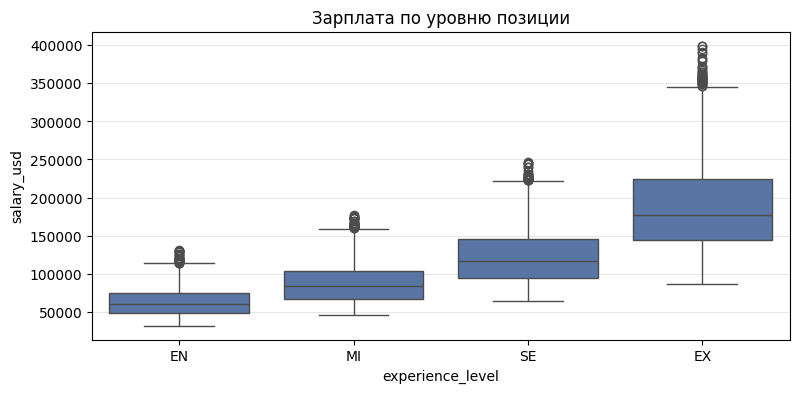

In [20]:
exp_order = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
d['exp_rank'] = d['experience_level'].map(exp_order)

print(d.groupby('experience_level')['salary_usd'].agg(
    ['count', 'median', 'mean']).reindex(['EN', 'MI', 'SE', 'EX']).round(0).to_string())

rho, p_rho = stats.spearmanr(d['exp_rank'], d['salary_usd'])
H, p_h = stats.kruskal(*[g['salary_usd'].values for _, g in d.groupby('experience_level')])
print(f'\nСпирмен:         rho = {rho:.3f},  p = {p_rho:.2e}')
print(f'Краскел-Уоллис:  H = {H:.1f},  p = {p_h:.2e}')

plt.figure(figsize=(9, 4))
sns.boxplot(data=d, x='experience_level', y='salary_usd', order=['EN', 'MI', 'SE', 'EX'])
plt.title('Зарплата по уровню позиции')
plt.show()

Это самая сильная связь среди выбранных предикторов: Спирмен 0,82. Краскел–Уоллис также показывает значимые различия: H = 9 988, p-value округляется до нуля.

Медианы растут с уровнем: EN 60 380 долл., MI 84 662 долл., SE 116 899 долл., EX 177 512 долл. Уровень позиции стоит проверить в модели.

### 3.3. Зарплата и размер компании

Для упорядоченных размеров S, M, L используем те же методы: Спирмена, Краскела–Уоллиса и boxplot.

              count    median      mean
company_size                           
S              5001   89652.0  102152.0
M              4987   98101.0  113576.0
L              4988  114536.0  130358.0

Спирмен:         rho = 0.194,  p = 7.05e-127
Краскел-Уоллис:  H = 569.1,  p = 2.68e-124


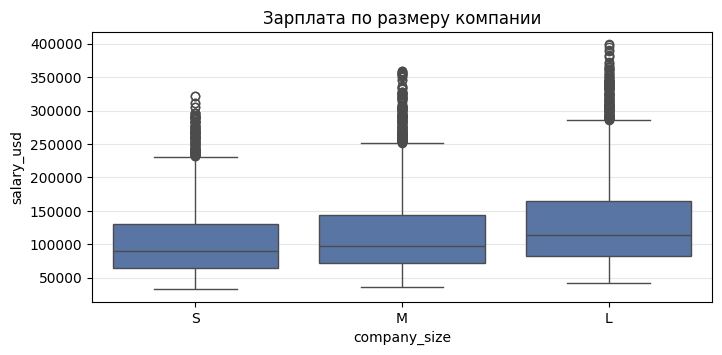

In [21]:
d['size_rank'] = d['company_size'].map({'S': 0, 'M': 1, 'L': 2})

print(d.groupby('company_size')['salary_usd'].agg(
    ['count', 'median', 'mean']).reindex(['S', 'M', 'L']).round(0).to_string())

rho, p_rho = stats.spearmanr(d['size_rank'], d['salary_usd'])
H, p_h = stats.kruskal(*[g['salary_usd'].values for _, g in d.groupby('company_size')])
print(f'\nСпирмен:         rho = {rho:.3f},  p = {p_rho:.2e}')
print(f'Краскел-Уоллис:  H = {H:.1f},  p = {p_h:.2e}')

plt.figure(figsize=(8, 3.5))
sns.boxplot(data=d, x='company_size', y='salary_usd', order=['S', 'M', 'L'])
plt.title('Зарплата по размеру компании')
plt.show()

Связь положительная, но слабая: Спирмен 0,19, p ≈ 7 × 10⁻¹²⁷. Медиана растёт от 89 652 долл. в небольших компаниях до 114 536 долл. в крупных, примерно на 28 %. При этом распределения зарплат сильно перекрываются.

### 3.4. Зарплата и формат работы

Сравним группы с помощью boxplot и критерия Краскела–Уоллиса. Спирменом проверим рост зарплаты при переходе от офиса к удалённой работе.

              count    median      mean
remote_ratio                           
0              5065   98756.0  114125.0
50             4995   99295.0  115792.0
100            4916  100592.0  116165.0



Краскел-Уоллис:  H = 4.18,  p = 0.124
Спирмен:         rho = 0.0167,  p = 0.041


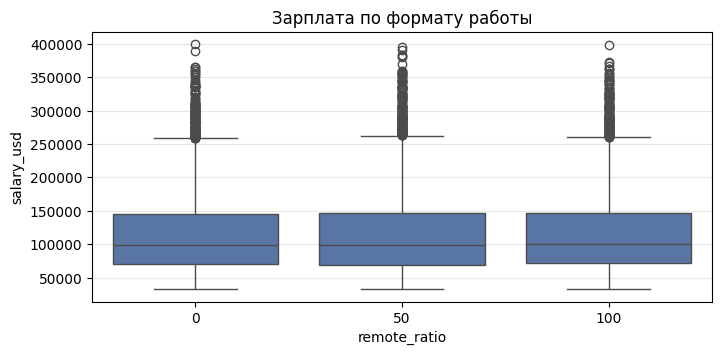

In [22]:
print(d.groupby('remote_ratio')['salary_usd'].agg(['count', 'median', 'mean']).round(0).to_string())

H, p_h = stats.kruskal(*[g['salary_usd'].values for _, g in d.groupby('remote_ratio')])
rho, p_rho = stats.spearmanr(d['remote_ratio'], d['salary_usd'])
print(f'\nКраскел-Уоллис:  H = {H:.2f},  p = {p_h:.3f}')
print(f'Спирмен:         rho = {rho:.4f},  p = {p_rho:.3f}')

plt.figure(figsize=(8, 3.5))
sns.boxplot(data=d, x='remote_ratio', y='salary_usd')
plt.title('Зарплата по формату работы')
plt.show()

Медианы близки: офис 98 756 долл., гибрид 99 295 долл., удалённая работа 100 592 долл. Разница меньше 2 %.

Краскел–Уоллис даёт p = 0,124: различия между группами незначимы на уровне 0,05. Для Спирмена p = 0,041: без поправки на множественные проверки положительная связь статистически значима, но пренебрежимо слаба (rho = 0,017). Тесты проверяют разные гипотезы: различия между группами и монотонный тренд. Оснований считать формат работы сильным предиктором зарплаты здесь нет.

### 3.5. Зарплата и требуемое образование

Сравним зарплаты по четырём стандартным уровням образования. Используем Краскела–Уоллиса и boxplot. Нестандартные значения пока исключим; исправим их в разделе 4.

                    count    median      mean
education_required                           
Associate            3780   99120.0  114593.0
Bachelor             3782   99069.0  115877.0
Master               3740  102554.0  117179.0
PhD                  3666   97153.0  113731.0

Краскел-Уоллис:  H = 6.83,  p = 0.077


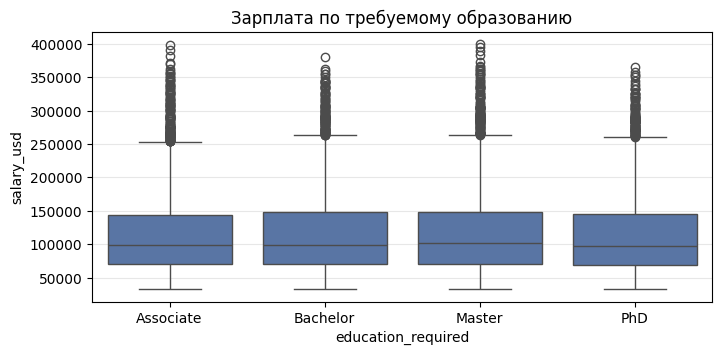

In [23]:
valid_edu = ['Associate', 'Bachelor', 'Master', 'PhD']
de = d[d['education_required'].isin(valid_edu)]

print(de.groupby('education_required')['salary_usd'].agg(
    ['count', 'median', 'mean']).reindex(valid_edu).round(0).to_string())

H, p_h = stats.kruskal(*[g['salary_usd'].values for _, g in de.groupby('education_required')])
print(f'\nКраскел-Уоллис:  H = {H:.2f},  p = {p_h:.3f}')

plt.figure(figsize=(8, 3.5))
sns.boxplot(data=de, x='education_required', y='salary_usd', order=valid_edu)
plt.title('Зарплата по требуемому образованию')
plt.show()

Медианы составляют 97 153–102 554 долл. и не растут с уровнем образования. При p = 0,077 различия не подтверждаются на уровне значимости 0,05. По этому сравнению образование не выглядит сильным предиктором.

### 3.6. Связи между предикторами

Проверим, насколько похожую информацию дают годы опыта и уровень позиции. Для числового и порядкового признаков используем Спирмена.

In [24]:
rho, p = stats.spearmanr(d['exp_rank'], d['years_experience'])
print(f'experience_level ~ years_experience:  rho = {rho:.3f}, p = {p:.2e}\n')
print(d.groupby('experience_level')['years_experience'].agg(
    ['min', 'median', 'max']).reindex(['EN', 'MI', 'SE', 'EX']).to_string())

experience_level ~ years_experience:  rho = 0.971, p = 0.00e+00

                  min  median  max
experience_level                  
EN                  0     0.0    1
MI                  2     3.0    4
SE                  5     7.0    9
EX                 10    15.0   19


Спирмен равен 0,97, p-value округляется до нуля. Уровни разделены по опыту: EN: 0–1 год, MI: 2–4, SE: 5–9, EX: 10–19.

Признаки тесно связаны. В линейной модели это может сделать коэффициенты неустойчивыми, поэтому стоит сравнить варианты с одним из них и с обоими.

Для уровня позиции и размера компании построим таблицу сопряжённости. Хи-квадрат проверит независимость категорий, V Крамера оценит силу связи без учёта их порядка.

In [25]:
ct = pd.crosstab(d['experience_level'], d['company_size']).reindex(
    index=['EN', 'MI', 'SE', 'EX'], columns=['S', 'M', 'L'])
print(ct.to_string())
print('\nДоли по строкам, %:')
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1).to_string())

chi2, p, dof, _ = stats.chi2_contingency(ct)
cramer_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f'\nХи-квадрат = {chi2:.2f}, df = {dof}, p = {p:.3f}')
print(f'V Крамера = {cramer_v:.3f}')

company_size         S     M     L
experience_level                  
EN                1265  1236  1212
MI                1218  1276  1282
SE                1224  1216  1295
EX                1294  1259  1199

Доли по строкам, %:
company_size         S     M     L
experience_level                  
EN                34.1  33.3  32.6
MI                32.3  33.8  34.0
SE                32.8  32.6  34.7
EX                34.5  33.6  32.0

Хи-квадрат = 9.83, df = 6, p = 0.132
V Крамера = 0.018


Доли размеров компаний почти одинаковы на всех уровнях. При p = 0,132 гипотеза независимости не отвергается, V Крамера равен 0,018.

Тепловая карта Спирмена ниже позволит сравнить связи числовых и упорядоченных признаков.

Для каждой пары на карте рассчитаем rho Спирмена, p-value и число наблюдений. Спирмен подходит для сравнения числовых и упорядоченных признаков: он оценивает монотонную связь по рангам, не предполагая равных расстояний между категориями. В таблице для каждой пары указаны типы шкал, знак и величина связи. Обозначения силы используем как ориентир: пренебрежимо слабая при |rho| < 0,1, слабая при 0,1–0,3, умеренная при 0,3–0,7, сильная от 0,7.

Из длины описания исключим значения вне 500–100 000 символов, из балла соцпакета вне 1–10; границы очистки разбираются в разделе 4.3. Пропуски исключаем отдельно для каждой пары. Для 21 одновременной проверки покажем как исходные p-value, так и p-value с поправкой Холма, которая учитывает множественные сравнения. Значимость оцениваем при 0,05.

,пара,шкалы,n,rho,p,направление,сила,p_Holm,p < 0.05,Holm < 0.05
0,salary_usd / years_experience,числовая / числовая,14976,0.7921,0,положительное,сильная,0,True,True
1,salary_usd / exp_rank,числовая / порядковая,14976,0.8162,0,положительное,сильная,0,True,True
2,salary_usd / size_rank,числовая / порядковая,14976,0.1940,7.05e-127,положительное,слабая,1.27e-125,True,True
3,salary_usd / remote_ratio,числовая / порядковая,14976,0.0167,0.041,положительное,пренебрежимо слабая,0.697,True,False
4,salary_usd / job_description_length,числовая / числовая,14962,-0.0065,0.426,отрицательное,пренебрежимо слабая,1,False,False
5,salary_usd / benefits_score,числовая / числовая,14959,-0.0049,0.548,отрицательное,пренебрежимо слабая,1,False,False
6,years_experience / exp_rank,числовая / порядковая,14976,0.9713,0,положительное,сильная,0,True,True
7,years_experience / size_rank,числовая / порядковая,14976,-0.0043,0.597,отрицательное,пренебрежимо слабая,1,False,False
8,years_experience / remote_ratio,числовая / порядковая,14976,0.0166,0.0418,положительное,пренебрежимо слабая,0.697,True,False
9,years_experience / job_description_length,числовая / числовая,14962,-0.0055,0.502,отрицательное,пренебрежимо слабая,1,False,False


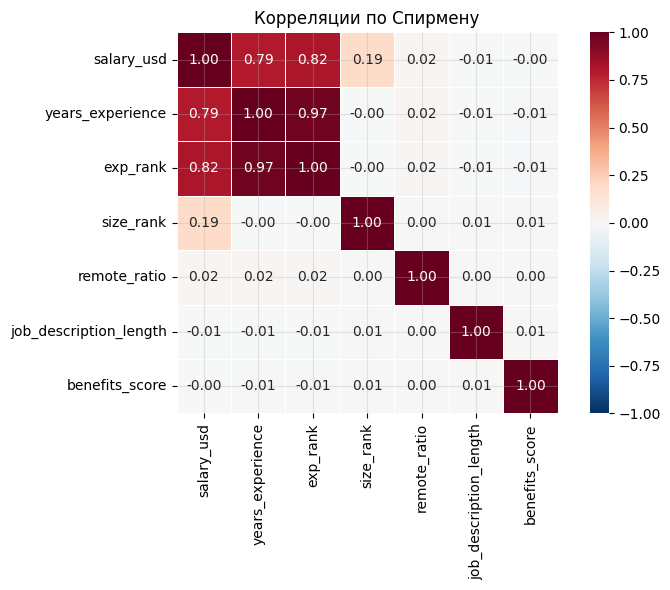

In [26]:
from itertools import combinations

num_cols = ['salary_usd', 'years_experience', 'exp_rank', 'size_rank',
            'remote_ratio', 'job_description_length', 'benefits_score']
dm = d[num_cols].copy()
dm.loc[~dm['job_description_length'].between(500, 1e5), 'job_description_length'] = np.nan
dm.loc[~dm['benefits_score'].between(1, 10), 'benefits_score'] = np.nan

scale_types = {col: 'числовая' for col in num_cols}
scale_types.update({col: 'порядковая' for col in ['exp_rank', 'size_rank', 'remote_ratio']})
rows = []
for left, right in combinations(num_cols, 2):
    pair = dm[[left, right]].dropna()
    rho, p = stats.spearmanr(pair[left], pair[right])
    magnitude = abs(rho)
    strength = ('пренебрежимо слабая' if magnitude < 0.1 else
                'слабая' if magnitude < 0.3 else
                'умеренная' if magnitude < 0.7 else 'сильная')
    rows.append({
        'пара': f'{left} / {right}',
        'шкалы': f'{scale_types[left]} / {scale_types[right]}',
        'n': len(pair), 'rho': rho, 'p': p,
        'направление': 'положительное' if rho > 0 else 'отрицательное' if rho < 0 else 'нет',
        'сила': strength,
    })
pair_results = pd.DataFrame(rows)
# Holm correction: sort p-values, adjust, and restore the original pair order.
order_p = np.argsort(pair_results['p'].to_numpy())
adjusted = np.minimum(1, np.maximum.accumulate(
    pair_results['p'].to_numpy()[order_p] * np.arange(len(pair_results), 0, -1)))
pair_results['p_Holm'] = 0.0
pair_results.loc[order_p, 'p_Holm'] = adjusted
pair_results['p < 0.05'] = pair_results['p'] < 0.05
pair_results['Holm < 0.05'] = pair_results['p_Holm'] < 0.05
display(pair_results.style.format({'rho': '{:.4f}', 'p': '{:.3g}', 'p_Holm': '{:.3g}'}))

plt.figure(figsize=(8, 6))
sns.heatmap(dm.corr(method='spearman'), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Корреляции по Спирмену')
plt.tight_layout()
plt.show()

Самая сильная связь на карте наблюдается между годами опыта и уровнем позиции. Оба признака сильно и положительно связаны с зарплатой; связь размера компании с зарплатой положительная, но слабая. Остальные коэффициенты по модулю меньше 0,1. Направление и значимость каждой пары приведены в таблице.

Длина описания и балл соцпакета не показывают заметной монотонной связи ни с зарплатой, ни с остальными признаками карты. После поправки Холма значимыми остаются четыре связи: зарплаты с опытом, уровнем и размером компании, а также опыта с уровнем. Связь формата работы с зарплатой, значимая в отдельном тесте, поправку не проходит.

Для дальнейшего анализа выделим уровень позиции, опыт и размер компании. Опыт почти дублирует уровень: их ранговая корреляция равна 0,97, а диапазоны стажа между уровнями не пересекаются. В разделе 5 отдельно проверим, добавляет ли отклонение опыта от медианы уровня информацию сверх самого уровня.

## 4. Предобработка данных

Обработаем пропуски и найденные ошибки в копии исходной таблицы.

In [27]:
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, StandardScaler

data = df.copy()
print(f'Исходный размер: {data.shape}')

Исходный размер: (15000, 19)


### 4.1. Преобразование форматов

Переведём строки с датами в `datetime`, и проверим, что дедлайн не раньше даты публикации.

In [28]:
for col in ['posting_date', 'application_deadline']:
    data[col] = pd.to_datetime(data[col], errors='coerce')
    print(f'{col}: нераспознанных {data[col].isna().sum()}, '
          f'период с {data[col].min().date()} по {data[col].max().date()}')

delta = (data['application_deadline'] - data['posting_date']).dt.days
print(f'\nСрок приёма заявок: от {delta.min()} до {delta.max()} дней')
print(f'Дедлайн раньше публикации: {(delta < 0).sum()} случаев')

posting_date: нераспознанных 0, период с 2024-01-01 по 2025-04-30
application_deadline: нераспознанных 0, период с 2024-01-16 по 2025-07-11

Срок приёма заявок: от 14 до 74 дней
Дедлайн раньше публикации: 0 случаев


Все даты распознаны. Публикации охватывают период с января 2024 по апрель 2025, хотя в задании упоминается только 2025 год. Срок приёма заявок составляет 14–74 дня, отрицательных сроков нет.

### 4.2. Пропуски

Удалим 10 строк без целевой переменной. Пропуски в числовых признаках заполним медианой, устойчивой к крайним значениям, а в категориальных модой. Для небольшого числа пропусков выберем эти простые способы.

In [29]:
before = len(data)
data = data.dropna(subset=['salary_usd'])
print(f'Удалено строк с пропуском целевой: {before - len(data)}')

for col in ['benefits_score', 'job_description_length']:
    n = data[col].isna().sum()
    if n:
        data[col] = data[col].fillna(data[col].median())
        print(f'{col}: заполнено медианой {n}')

for col in ['education_required', 'industry', 'employee_residence']:
    n = data[col].isna().sum()
    if n:
        data[col] = data[col].fillna(data[col].mode()[0])
        print(f'{col}: заполнено модой {n}')

print(f'\nОсталось пропусков: {data.isna().sum().sum()}')

Удалено строк с пропуском целевой: 10
benefits_score: заполнено медианой 16
job_description_length: заполнено медианой 8
education_required: заполнено модой 5
industry: заполнено модой 3
employee_residence: заполнено модой 2

Осталось пропусков: 0


Уберём пробелы по краям значений и заменим `Associate.` на `Associate`, `Ph` будем считать сокращением `PhD`. Значение `6` восстановить нельзя, поэтому заменим его модой.

In [30]:
data['education_required'] = data['education_required'].str.strip().replace({
    'Associate.': 'Associate', 'Ph': 'PhD',
})
mode_edu = data['education_required'].mode()[0]
data.loc[~data['education_required'].isin(
    ['Associate', 'Bachelor', 'Master', 'PhD']), 'education_required'] = mode_edu

print(data['education_required'].value_counts().to_string())

education_required
Bachelor     3790
Associate    3781
Master       3746
PhD          3673


В отраслях исправим пробелы, регистр, опечатки и сокращения. Вместо `9999` поставим наиболее частую отрасль.

In [31]:
print(f'До очистки уникальных значений: {data["industry"].nunique()}')

data['industry'] = data['industry'].str.strip().str.title()
data['industry'] = data['industry'].replace({
    'Retail_': 'Retail',
    'Transport': 'Transportation',
    'Telecom': 'Telecommunications',
    'Governmnt': 'Government',
})
mode_ind = data.loc[data['industry'] != '9999', 'industry'].mode()[0]
data.loc[data['industry'] == '9999', 'industry'] = mode_ind

print(f'После очистки: {data["industry"].nunique()}\n')
print(data['industry'].value_counts().to_string())

До очистки уникальных значений: 23
После очистки: 15

industry
Retail                1067
Media                 1044
Consulting            1019
Automotive            1018
Technology            1010
Real Estate           1006
Government             998
Healthcare             997
Telecommunications     996
Transportation         995
Finance                983
Energy                 975
Gaming                 965
Manufacturing          961
Education              956


После очистки осталось 15 отраслей.

В `employee_residence` уберём пробелы, раскроем `US` как `United States`, а `UK` как `United Kingdom`. Значение `8888` не обозначает страну, поэтому заменим его наиболее частым названием страны.

In [32]:
print(f'До очистки стран: {data["employee_residence"].nunique()} уникальных значения')
data['employee_residence'] = data['employee_residence'].str.strip().replace({
    'US': 'United States', 'UK': 'United Kingdom', '8888': np.nan,
})
data['employee_residence'] = data['employee_residence'].fillna(
    data['employee_residence'].mode()[0])
print(f'После очистки: {data["employee_residence"].nunique()} стран')
print(data['employee_residence'].value_counts().to_string())

До очистки стран: 24 уникальных значения
После очистки: 20 стран
employee_residence
Sweden            791
France            779
Denmark           777
Austria           776
India             772
Germany           768
South Korea       763
Canada            762
China             760
Netherlands       757
Switzerland       748
United Kingdom    748
Ireland           740
Singapore         739
Israel            731
Australia         730
Norway            725
United States     716
Finland           708
Japan             700


После объединения вариантов написания и замены `8888` осталось 20 стран.

### 4.3. Выбросы

Проверим зарплату, балл соцпакета и длину описания. Высокие зарплаты, отмеченные только правилом Тьюки, сохраним.

In [33]:
print('Наименьшие длины описания:', data['job_description_length'].nsmallest(12).to_list())
print('Наибольшие длины описания:', data['job_description_length'].nlargest(5).to_list())

checks = {
    'salary_usd': (data['salary_usd'] < 1000) | (data['salary_usd'] > 1e6),
    'benefits_score': (data['benefits_score'] < 1) | (data['benefits_score'] > 10),
    'job_description_length': (data['job_description_length'] < 500) | (data['job_description_length'] > 1e5),
}
for col, mask in checks.items():
    print(f'{col}: {mask.sum()} за выбранными границами -> {sorted(data.loc[mask, col].unique())[:6]}')

Наименьшие длины описания: [-3.0, 0.0, 1.0, 6.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 501.0, 501.0]
Наибольшие длины описания: [999999999.0, 9999999.0, 2499.0, 2499.0, 2499.0]
salary_usd: 14 за выбранными границами -> [np.float64(-999.0), np.float64(-78.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(3.0)]
benefits_score: 1 за выбранными границами -> [np.float64(9999.0)]
job_description_length: 6 за выбранными границами -> [np.float64(-3.0), np.float64(0.0), np.float64(1.0), np.float64(6.0), np.float64(9999999.0), np.float64(999999999.0)]


Для зарплаты применим выбранные в разделе 2.1 границы 1 000–1 млн долларов в год. Они отделяют 14 подозрительных наблюдений от основной группы.

Соцпакет должен быть в диапазоне 1–10. В длине описания выделяются шесть значений: −3, 0, 1, 6, 9 999 999 и 999 999 999. Остальные наблюдаемые значения лежат в диапазоне 500–2 499. Отрицательная длина недопустима, а остальные пять значений считаем подозрительными из-за отрыва от основной группы. Для этой выборки примем границы 500–100 000 символов: они отделяют все шесть значений, не затрагивая основную группу.

Строки с зарплатой за выбранными границами удалим. Значения длины описания и балла соцпакета за границами заменим медианами допустимых значений.

In [34]:
before = len(data)
data = data[~checks['salary_usd'].reindex(data.index, fill_value=False)]
print(f'Удалено строк с зарплатой за выбранными границами: {before - len(data)}')

for col in ['benefits_score', 'job_description_length']:
    mask = checks[col].reindex(data.index, fill_value=False)
    if mask.sum():
        data.loc[mask, col] = data.loc[~mask, col].median()
        print(f'{col}: заменено медианой {mask.sum()}')

print(f'\nИтоговый размер: {data.shape}')
print(data[['salary_usd', 'benefits_score', 'job_description_length']].describe().round(1).to_string())

Удалено строк с зарплатой за выбранными границами: 14
benefits_score: заменено медианой 1
job_description_length: заменено медианой 6

Итоговый размер: (14976, 19)
       salary_usd  benefits_score  job_description_length
count     14976.0         14976.0                 14976.0
mean     115350.5             7.5                  1503.3
std       60267.7             1.4                   576.0
min       32519.0             5.0                   500.0
25%       70187.5             6.2                  1004.0
50%       99658.5             7.5                  1512.0
75%      146408.5             8.8                  2000.0
max      399095.0            10.0                  2499.0


Осталось 14 976 вакансий без пропусков. Зарплаты лежат в диапазоне 32 519–399 095 долл., соцпакет 5–10 баллов, длина описания 500–2 499 символов.

Стандартное отклонение зарплаты снизилось с 825 до 60 тысяч долларов: исключённые крайние значения сильно увеличивали разброс.

### 4.4. Масштабирование и трансформация

Для зарплаты и опыта сравним стандартизацию, min-max и Йео–Джонсона. Для скошенного распределения зарплат также попробуем логарифм. Изменения формы покажем на гистограммах.

In [35]:
num = data[['salary_usd', 'years_experience']].copy()

std = pd.DataFrame(StandardScaler().fit_transform(num),
                   columns=['salary_std', 'years_std'], index=num.index)
mm = pd.DataFrame(MinMaxScaler().fit_transform(num),
                  columns=['salary_minmax', 'years_minmax'], index=num.index)
log_salary = np.log(num['salary_usd']).rename('salary_log')
yj = pd.DataFrame(PowerTransformer(method='yeo-johnson').fit_transform(num),
                  columns=['salary_yj', 'years_yj'], index=num.index)

transforms = {
    'Зарплата': {
        'исходный': num['salary_usd'],
        'стандартизация': std['salary_std'],
        'min-max': mm['salary_minmax'],
        'логарифм': log_salary,
        'Йео-Джонсон': yj['salary_yj'],
    },
    'Опыт': {
        'исходный': num['years_experience'],
        'стандартизация': std['years_std'],
        'min-max': mm['years_minmax'],
        'Йео-Джонсон': yj['years_yj'],
    },
}
for feature, variants in transforms.items():
    print(f'\n{feature}:')
    summary = pd.DataFrame({name: values.describe() for name, values in variants.items()})
    summary.loc['skew'] = pd.Series({name: values.skew() for name, values in variants.items()})
    print(summary.round(3).to_string())


Зарплата:
         исходный  стандартизация    min-max   логарифм  Йео-Джонсон
count   14976.000       14976.000  14976.000  14976.000    14976.000
mean   115350.470           0.000      0.226     11.532       -0.000
std     60267.741           1.000      0.164      0.496        1.000
min     32519.000          -1.374      0.000     10.390       -2.448
25%     70187.500          -0.749      0.103     11.159       -0.741
50%     99658.500          -0.260      0.183     11.510       -0.015
75%    146408.500           0.515      0.311     11.894        0.747
max    399095.000           4.708      1.000     12.897        2.573
skew        1.254           1.254      1.254      0.140        0.012

Опыт:
        исходный  стандартизация    min-max  Йео-Джонсон
count  14976.000       14976.000  14976.000    14976.000
mean       6.252          -0.000      0.329        0.000
std        5.546           1.000      0.292        1.000
min        0.000          -1.127      0.000       -1.627
25%    

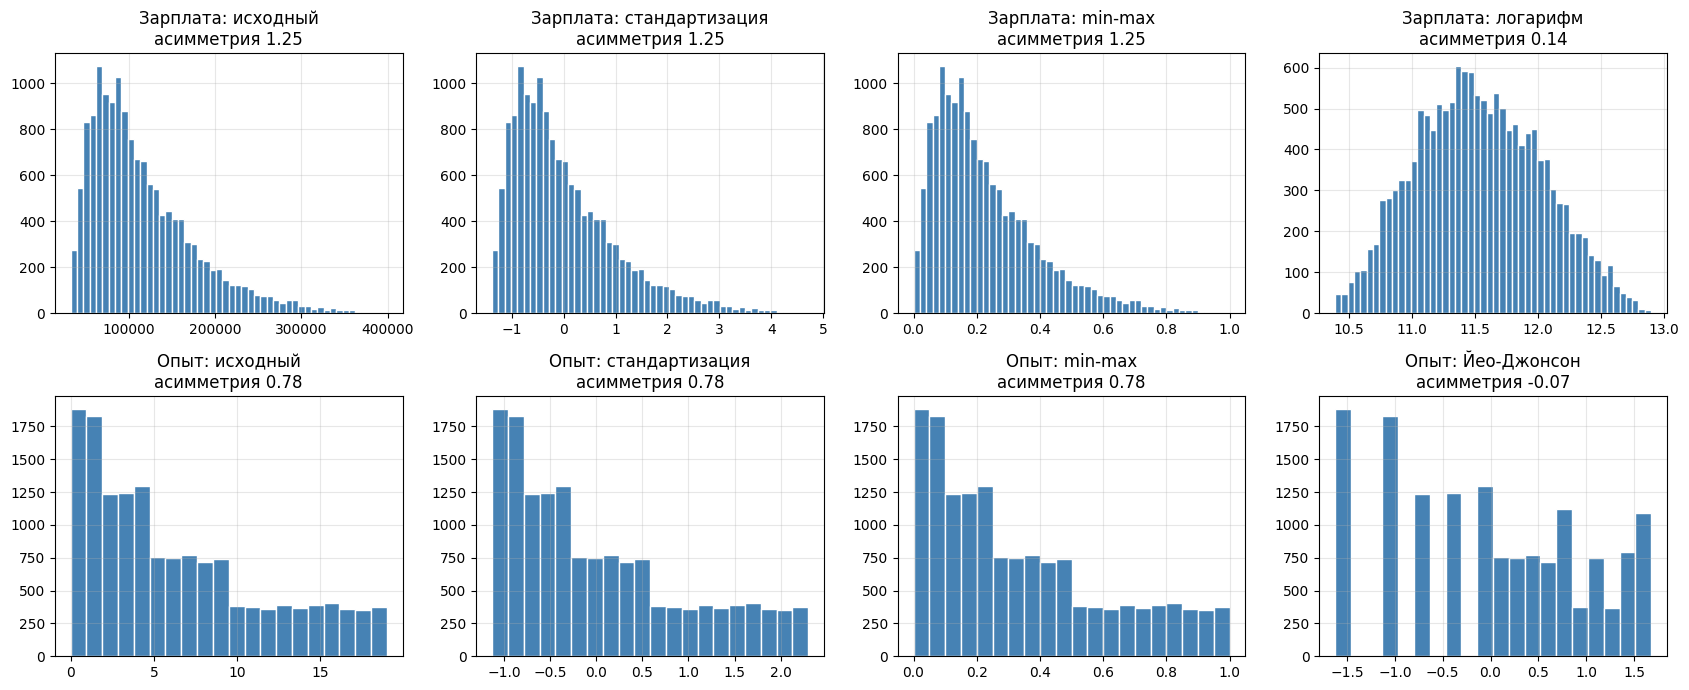

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for row, feature in enumerate(['Зарплата', 'Опыт']):
    variants = transforms[feature]
    names = ['исходный', 'стандартизация', 'min-max',
             'логарифм' if feature == 'Зарплата' else 'Йео-Джонсон']
    for ax, name in zip(axes[row], names):
        values = variants[name]
        ax.hist(values, bins=50 if row == 0 else 20, color='steelblue', edgecolor='white')
        ax.set_title(f'{feature}: {name}\nасимметрия {values.skew():.2f}')
plt.tight_layout()
plt.show()

Стандартизация даёт обоим признакам среднее 0 и дисперсию 1, а min-max приводит их к диапазону [0, 1]. Форма распределений сохраняется: асимметрия зарплаты остаётся 1,25.

Логарифм снижает её до 0,14, Йео–Джонсон до 0,01. Для зарплаты выберем логарифм как более простой вариант. 

Для опыта стандартизация и min-max сохраняют асимметрию 0,78. Йео–Джонсон снижает её до −0,07 и допускает нулевой опыт. Распределение становится ближе к симметричному, но значения теряют привычный смысл числа лет. Для модели можно сравнить масштабированный опыт и вариант Йео–Джонсона.

При обучении модели параметры преобразований следует рассчитывать только на обучающей выборке.

### 4.5. Кодирование категориального признака

Закодируем уровни EN, MI, SE, EX числами 0, 1, 2, 3 и сравним с one-hot. Первый вариант сохраняет порядок, второй создаёт отдельный столбец для каждого уровня.

In [37]:
encoded = data[['experience_level', 'salary_usd']].copy()
encoded['exp_ordinal'] = encoded['experience_level'].map({'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3})
onehot = pd.get_dummies(data['experience_level'], prefix='exp').astype(int)

print(f'One-hot: добавлено {onehot.shape[1]} столбца')
print(onehot.head(3).to_string())

rho, _ = stats.spearmanr(encoded['exp_ordinal'], encoded['salary_usd'])
print(f'\nСвязь порядкового кода с зарплатой: rho = {rho:.3f}')

med = encoded.groupby('exp_ordinal')['salary_usd'].median()
print('\nМедианная зарплата по кодам:')
print(med.round(0).to_string())
print(f'Приросты: {[f"{v:,.0f}" for v in med.diff().dropna().values]}')

One-hot: добавлено 4 столбца
   exp_EN  exp_EX  exp_MI  exp_SE
0       0       0       0       1
1       1       0       0       0
2       0       0       1       0

Связь порядкового кода с зарплатой: rho = 0.816

Медианная зарплата по кодам:
exp_ordinal
0     60380.0
1     84662.0
2    116899.0
3    177512.0
Приросты: ['24,282', '32,236', '60,613']


Порядковое кодирование сохранило rho = 0,82. Но приросты медианных зарплат между уровнями разные: 24 282, 32 236 и 60 613 долл.

Линейная модель с одним кодом 0–3 задавала бы одинаковый прирост за каждый шаг. Для неё лучше проверить one-hot; для деревьев подойдёт порядковый код. Сохраним оба варианта.

In [38]:
data['exp_ordinal'] = data['experience_level'].map({'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3})
data = pd.concat([data, onehot], axis=1)
data[['salary_std', 'salary_log']] = pd.concat([std['salary_std'], log_salary], axis=1)
print(f'Размер после предобработки: {data.shape}')

Размер после предобработки: (14976, 26)


## 5. Конструирование признаков

### 5.1. Число требуемых навыков

Создадим `n_skills`, количество навыков в списке `required_skills`. Гипотеза: больше требований соответствует более высокой зарплате. Проверим её по медианам и Спирмену.

In [39]:
data['n_skills'] = data['required_skills'].str.split(',').str.len()

print(data.groupby('n_skills')['salary_usd'].agg(['count', 'median']).round(0).to_string())
rho, p = stats.spearmanr(data['n_skills'], data['salary_usd'])
print(f'\nСвязь с зарплатой: rho = {rho:.4f}, p = {p:.3f}')

          count    median
n_skills                 
3          5039  100703.0
4          4998   99207.0
5          4939   98908.0

Связь с зарплатой: rho = -0.0132, p = 0.106


Для 3, 4 и 5 навыков медианные зарплаты равны 100 703, 99 207 и 98 908 долл. Ожидаемого роста нет: rho = −0,013, p = 0,106. Гипотеза не подтвердилась.

### 5.2. Зарплатный индекс страны

`country_salary_index` равен медианной зарплате в стране компании, делённой на общую медиану. Значение 1,2 означает, что типичная зарплата в стране на 20 % выше, чем в целом по выборке. Индекс сводит 20 стран к одному числу, которое отражает уровень оплаты на рынке страны. В разделе 3 страну мы не рассматривали.

Гипотеза: страна сдвигает зарплату независимо от уровня позиции, поэтому индекс добавит информацию сверх уровня и размера компании.

Индекс рассчитывается по целевой переменной. Чтобы он не использовал зарплаты, на которых мы его проверяем, медианы считаем только на обучающей части (70 %), а связь и качество модели оцениваем на тестовой (30 %). Проверим Спирмена в целом и внутри каждого уровня, затем сравним Ridge-регрессию логарифма зарплаты с индексом и без него.

Индекс по странам (обучающая часть):
company_location
Ireland           0.74
China             0.76
Austria           0.77
Israel            0.77
South Korea       0.79
Japan             0.80
India             0.80
Finland           0.82
Canada            1.01
Australia         1.03
France            1.03
Germany           1.07
Sweden            1.07
Netherlands       1.11
United Kingdom    1.12
Singapore         1.13
United States     1.27
Norway            1.40
Denmark           1.46
Switzerland       1.54

Связь с зарплатой на тестовой части: rho = 0.475, p = 3.22e-252

Связь внутри уровней (тестовая часть):
            n     rho    p
уровень                   
EN       1048  0.7825  0.0
MI       1175  0.8077  0.0
SE       1123  0.8037  0.0
EX       1147  0.7343  0.0

Ridge, разбиение 70/30; чем меньше MAE, тем лучше:
                                  MAE(log зарплаты)
вариант                                            
Уровень + размер компании                    0.2326
Уровень + р

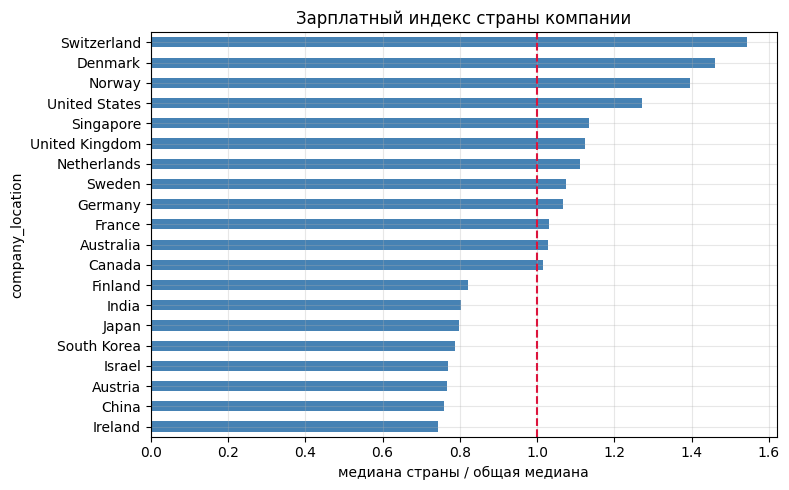

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

train_idx, test_idx = train_test_split(data.index, test_size=0.3, random_state=42)
train_salary = data.loc[train_idx, 'salary_usd']
country_index = (train_salary.groupby(data.loc[train_idx, 'company_location']).median()
                 / train_salary.median()).sort_values()
data['country_salary_index'] = data['company_location'].map(country_index)

print('Индекс по странам (обучающая часть):')
print(country_index.round(2).to_string())

test = data.loc[test_idx]
rho, p = stats.spearmanr(test['country_salary_index'], test['salary_usd'])
print(f'\nСвязь с зарплатой на тестовой части: rho = {rho:.3f}, p = {p:.2e}')

within_level = []
for level in ['EN', 'MI', 'SE', 'EX']:
    part = test[test['experience_level'].eq(level)]
    rho_l, p_l = stats.spearmanr(part['country_salary_index'], part['salary_usd'])
    within_level.append({'уровень': level, 'n': len(part), 'rho': rho_l, 'p': p_l})
print('\nСвязь внутри уровней (тестовая часть):')
print(pd.DataFrame(within_level).set_index('уровень').round(4).to_string())

model_rows = []
for add_feature in [False, True]:
    cats = ['experience_level', 'company_size']
    transformers = [('categories', OneHotEncoder(handle_unknown='ignore'), cats)]
    cols = cats.copy()
    if add_feature:
        cols.append('country_salary_index')
        transformers.append(('country', 'passthrough', ['country_salary_index']))
    model = make_pipeline(ColumnTransformer(transformers), Ridge(alpha=10))
    X_train, X_test = data.loc[train_idx, cols].copy(), data.loc[test_idx, cols].copy()
    if add_feature:
        X_train['country_salary_index'] = np.log(X_train['country_salary_index'])
        X_test['country_salary_index'] = np.log(X_test['country_salary_index'])
    model.fit(X_train, np.log(data.loc[train_idx, 'salary_usd']))
    prediction = model.predict(X_test)
    model_rows.append({
        'вариант': 'Уровень + размер + индекс страны' if add_feature else 'Уровень + размер компании',
        'MAE(log зарплаты)': mean_absolute_error(np.log(data.loc[test_idx, 'salary_usd']), prediction),
    })
country_comparison = pd.DataFrame(model_rows).set_index('вариант')
print('\nRidge, разбиение 70/30; чем меньше MAE, тем лучше:')
print(country_comparison.round(4).to_string())

country_index.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.axvline(1, color='crimson', ls='--')
plt.title('Зарплатный индекс страны компании')
plt.xlabel('медиана страны / общая медиана')
plt.tight_layout()
plt.show()


Индекс разделяет страны на группы. У Ирландии, Китая, Австрии, Израиля, Южной Кореи, Японии, Индии и Финляндии он равен 0,74–0,82. У Канады, Австралии, Франции, Германии, Швеции, Нидерландов, Великобритании и Сингапура он составляет 1,01–1,13. У США индекс равен 1,27, у Норвегии, Дании и Швейцарии 1,40–1,54.

На тестовой части связь с зарплатой умеренная и положительная: rho = 0,475, p ≈ 3 × 10⁻²⁵². Внутри каждого уровня она сильная: rho от 0,73 до 0,81. В общей выборке влияние страны частично скрыто большими различиями между уровнями; при одинаковом уровне позиции зарплата тесно связана со страной.

С индексом MAE логарифма зарплаты снижается с 0,233 до 0,120, почти вдвое. Гипотеза подтвердилась. При обучении модели индекс нужно пересчитывать по каждой обучающей выборке.

### 5.3. Опыт относительно своего уровня

В `exp_above_level` вычтем из опыта медиану соответствующего уровня. Так получим отклонение от типичных требований внутри категории. Проверим его связь с зарплатой по Спирмену и графику медиан. Затем проверим связь отдельно внутри EN, MI, SE и EX: общий коэффициент может отражать различия между уровнями. Дополнительную ценность оценим сравнением моделей на одной и той же проверочной выборке.

count    14976.00
mean        -0.01
std          1.70
min         -5.00
25%         -1.00
50%          0.00
75%          1.00
max          4.00

Связь с зарплатой: rho = -0.1379, p = 1.81e-64


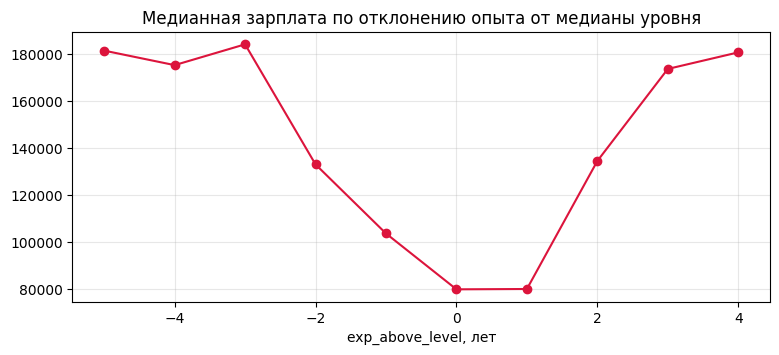

Связь внутри уровней:
            n     rho       p
уровень                      
EN       3713  0.0048  0.7698
MI       3776 -0.0167  0.3036
SE       3735  0.0192  0.2399
EX       3752 -0.0247  0.1309

Ridge, одинаковое разбиение 70/30; чем меньше MAE, тем лучше:
                           MAE(log зарплаты)
вариант                                     
Уровень и размер компании           0.232572
С отклонением опыта                 0.232548


In [41]:
level_median = data.groupby('experience_level')['years_experience'].transform('median')
data['exp_above_level'] = data['years_experience'] - level_median

print(data['exp_above_level'].describe().round(2).to_string())
rho, p = stats.spearmanr(data['exp_above_level'], data['salary_usd'])
print(f'\nСвязь с зарплатой: rho = {rho:.4f}, p = {p:.2e}')

plt.figure(figsize=(9, 3.5))
data.groupby('exp_above_level')['salary_usd'].median().plot(marker='o', color='crimson')
plt.title('Медианная зарплата по отклонению опыта от медианы уровня')
plt.xlabel('exp_above_level, лет')
plt.show()

within_level = []
for level in ['EN', 'MI', 'SE', 'EX']:
    part = data.loc[data['experience_level'].eq(level)]
    rho, p = stats.spearmanr(part['exp_above_level'], part['salary_usd'])
    within_level.append({'уровень': level, 'n': len(part), 'rho': rho, 'p': p})
print('Связь внутри уровней:')
print(pd.DataFrame(within_level).set_index('уровень').round(4).to_string())

train, test = train_test_split(data, test_size=0.3, random_state=42)
train, test = train.copy(), test.copy()
train_medians = train.groupby('experience_level')['years_experience'].median()
for part in [train, test]:
    part['exp_above_level'] = part['years_experience'] - part['experience_level'].map(train_medians)

model_rows = []
for add_feature in [False, True]:
    cats = ['experience_level', 'company_size']
    transformers = [('categories', OneHotEncoder(handle_unknown='ignore'), cats)]
    cols = cats.copy()
    if add_feature:
        cols.append('exp_above_level')
        transformers.append(('deviation', 'passthrough', ['exp_above_level']))
    model = make_pipeline(ColumnTransformer(transformers), Ridge(alpha=10))
    model.fit(train[cols], np.log(train['salary_usd']))
    prediction = model.predict(test[cols])
    model_rows.append({'вариант': 'С отклонением опыта' if add_feature else 'Уровень и размер компании',
                       'MAE(log зарплаты)': mean_absolute_error(np.log(test['salary_usd']), prediction)})
experience_comparison = pd.DataFrame(model_rows).set_index('вариант')
print('\nRidge, одинаковое разбиение 70/30; чем меньше MAE, тем лучше:')
print(experience_comparison.round(6).to_string())

В общей выборке rho = −0,138, p ≈ 1,8 × 10⁻⁶⁴. Однако отклонения от −5 до −3 и от 3 до 4 лет встречаются только у EX. Высокие зарплаты по краям общего графика отражают состав групп, а не рост оплаты за отклонение опыта.

Внутри каждого уровня связь пренебрежимо слаба: rho от −0,025 до 0,019, все p > 0,13. Рост зарплаты с отклонением стажа внутри уровня не подтверждается.

Для проверки прогноза сравнили Ridge-регрессию логарифма зарплаты по уровню позиции и размеру компании с той же моделью, дополненной отклонением опыта. Медианы уровней рассчитаны только на обучающей части. На одинаковом разбиении 70/30 MAE изменилась с 0,232572 до 0,232548: снижение около 0,01%. Заметной дополнительной пользы сверх уровня позиции в этих проверках не обнаружено.

### 5.4. Итог

Самым полезным новым признаком оказался индекс страны: внутри уровней позиции rho = 0,73–0,81, а ошибка модели снижается почти вдвое. Связь зарплаты с числом навыков не подтвердилась. Общая корреляция отклонения опыта с зарплатой не повторяется внутри уровней; добавление этого признака в модель снизило ошибку лишь на 0,01 %.

Основные кандидаты для моделирования: уровень позиции, страна компании и размер компании. Опыт тесно связан с уровнем и не показал заметной связи с зарплатой внутри него. Обработаны пропуски, найденные варианты написания категорий и значения за выбранными границами; варианты преобразований подготовлены.

**Использование ИИ.** Claude использовался для подготовки кода и пояснений, Codex использовался для редактирования текста, исправления кода и проверки результатов.